
# 02. 순서대로 키우기, seed 4개로 확인

규칙 세계 v1, 처음 보는 조합(composition), seed 42–45.

- **1단계 (읽기 배우기)**: 언어 부품(mDeBERTa-NLI)과 단순 판단기를 최종 답만으로 함께 학습한다. 4에폭이고, 언어 부품을 저장한다.
- **2단계 (판단 배우기)**: 그 언어 부품을 고정하고, 출처 구조 판단기만 새로 학습한다.
- **기준**: 출처 구조 판단기가 사람이 설계한 정답 메시지를 받으면 seed 4개 모두 1.00이다.

질문: 순서대로 키우면 판단기가 나아지는가? 나아지지 않는 부분은 어디서 오는가?


In [1]:

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = [42, 43, 44, 45]
stage1 = {s: S.interface_result("interface-anchored-learned", seed=s) for s in SEEDS}
staged = {s: S.interface_result("interface-anchored-learned-sourcefold-staged-frozen", seed=s) for s in SEEDS}
designed = {s: S.interface_result("interface-anchored-designed-sourcefold", seed=s) for s in SEEDS}



## 1. seed마다: 1단계 → 순서대로 키운 뒤

선 하나가 seed 하나다. 위로 올라가면 순서대로 키운 쪽이 낫다는 뜻이다.


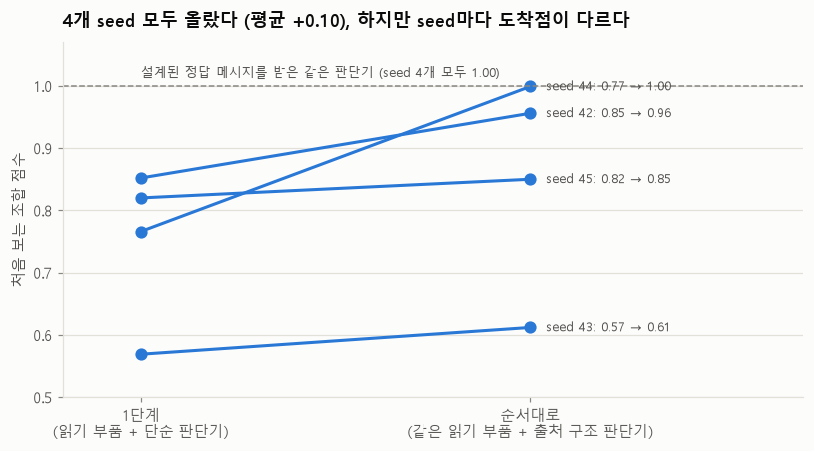

In [2]:

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for s in SEEDS:
    a, b = stage1[s]["score"], staged[s]["score"]
    ax.plot([0, 1], [a, b], "-o", color=V.BLUE, markersize=7, linewidth=2)
    ax.text(1.04, b, f"seed {s}: {a:.2f} → {b:.2f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.axhline(1.0, color=V.MUTED, linestyle="--", linewidth=1)
ax.text(0.0, 1.01, "설계된 정답 메시지를 받은 같은 판단기 (seed 4개 모두 1.00)", fontsize=8.5, color=V.TEXT_SECONDARY, va="bottom")
ax.set_xticks([0, 1], ["1단계\n(읽기 부품 + 단순 판단기)", "순서대로\n(같은 읽기 부품 + 출처 구조 판단기)"])
ax.set_xlim(-0.2, 1.7)
ax.set_ylim(0.5, 1.07)
ax.grid(axis="x", visible=False)
ax.set_ylabel("처음 보는 조합 점수")
diffs = [staged[s]["score"] - stage1[s]["score"] for s in SEEDS]
ax.set_title(f"4개 seed 모두 올랐다 (평균 +{sum(diffs) / len(diffs):.2f}), 하지만 seed마다 도착점이 다르다", pad=10)
fig.tight_layout()
plt.show()



## 2. 어디서 틀리나: 사례 종류별 점수

색은 점수다. 파랑은 맞힘(+1), 회색은 0, 빨강은 틀림(−1)이다. 오른쪽 열은 언어 부품의 품질(메시지 탐침)이다.


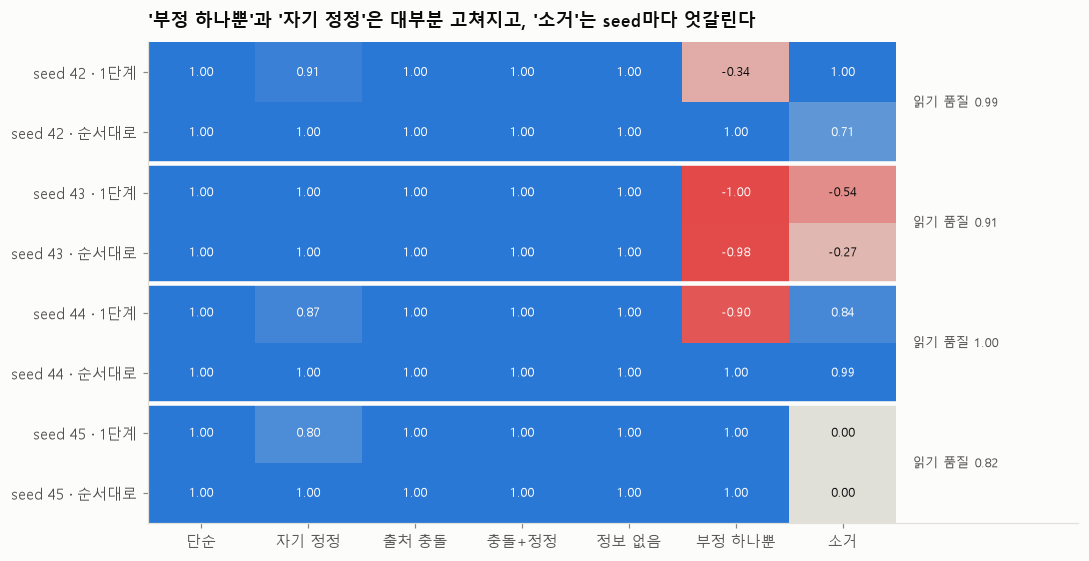

In [3]:

cases = ["simple", "self_correction", "conflict", "conflict_correction", "none", "one_negative", "elimination"]
case_names = ["단순", "자기 정정", "출처 충돌", "충돌+정정", "정보 없음", "부정 하나뿐", "소거"]
rows, labels = [], []
for s in SEEDS:
    for name, runs in (("1단계", stage1), ("순서대로", staged)):
        rows.append([runs[s]["by_case"][c] for c in cases])
        labels.append(f"seed {s} · {name}")
cmap = LinearSegmentedColormap.from_list("score", ["#e34948", "#e1e0d9", V.BLUE])
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.imshow(rows, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
for i, row in enumerate(rows):
    for j, value in enumerate(row):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.6 else V.TEXT)
for i, s in enumerate(SEEDS):
    ax.text(len(cases) - 0.35, 2 * i + 0.5, f"읽기 품질 {stage1[s]['probe']:.2f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xticks(range(len(cases)), case_names)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlim(-0.5, len(cases) + 1.2)
ax.grid(False)
for i in range(1, len(SEEDS)):
    ax.axhline(2 * i - 0.5, color=V.SURFACE, linewidth=3)
ax.set_title("'부정 하나뿐'과 '자기 정정'은 대부분 고쳐지고, '소거'는 seed마다 엇갈린다", pad=10)
fig.tight_layout()
plt.show()



**읽는 법**
- **판단기가 고친 것**: "부정 하나뿐 → 모름"과 "자기 정정"은 처음 보는 출처 조합에서 판단기가 외워서 틀리던 사례다. 출처 구조 판단기로 바꾸자 seed 42, 44, 45에서 고쳐졌다.
- **판단기가 못 고친 것**: "소거"는 두 개의 "안 열린다"를 정확히 읽어야 풀 수 있다. 읽기 품질이 낮은 seed(43: 0.91, 45: 0.82)에서는 판단기를 바꿔도 소거가 그대로 틀렸다. seed 43은 "부정 하나뿐"도 그대로였다.
- **새 판단기가 오히려 나빠진 곳**: seed 42는 읽기 품질이 0.99인데도 소거가 1.00에서 0.71로 떨어졌다. 그래서 오류를 "읽기 탓"과 "판단 탓"으로 깔끔하게 나눌 수는 없다. 고정된 메시지에서 새 판단기가 배운 방식이 단순 판단기와 다르기 때문으로 보인다.
- 정리하면, 읽기 품질이 낮으면 판단기로 메울 수 없다. 다만 읽기 품질이 높아도 새 판단기가 모든 사례를 보장하지는 않는다.



## 3. 2단계 비용: 고정된 언어 부품의 메시지를 저장해 재사용

seed 42는 저장 없이 실행했다. seed 43–45는 고정된 언어 부품의 메시지를 한 번만 계산했다.


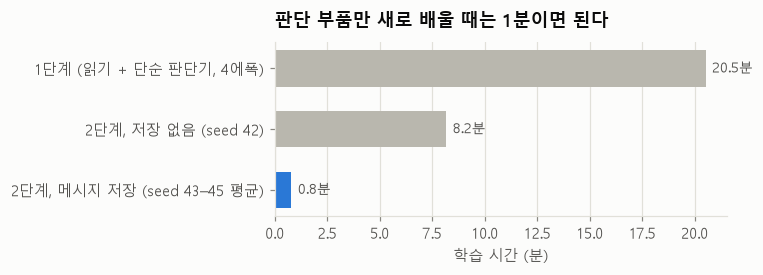

In [4]:

fig, ax = plt.subplots(figsize=(7, 2.6))
labels = ["1단계 (읽기 + 단순 판단기, 4에폭)", "2단계, 저장 없음 (seed 42)", "2단계, 메시지 저장 (seed 43–45 평균)"]
values = [sum(stage1[s]["seconds"] for s in SEEDS) / 4 / 60, staged[42]["seconds"] / 60,
          sum(staged[s]["seconds"] for s in (43, 44, 45)) / 3 / 60]
colors = [V.NEUTRAL, V.NEUTRAL, V.BLUE]
for i, (value, color) in enumerate(zip(values, colors)):
    ax.barh(i, value, height=0.6, color=color)
    ax.text(value + 0.3, i, f"{value:.1f}분", va="center", fontsize=9, color=V.TEXT_SECONDARY)
ax.set_yticks(range(3), labels)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("학습 시간 (분)")
ax.set_title("판단 부품만 새로 배울 때는 1분이면 된다", pad=10)
fig.tight_layout()
plt.show()



## 4. 정리

1. **순서대로 키우기는 매번 학습된다.** 처음부터 같이 배우면 멈췄던 출처 구조 판단기가(seed 42에서 −0.11), 읽기를 먼저 배운 뒤에는 seed 4개 모두 학습되었다.
2. **4개 seed 모두 1단계보다 올랐다**(평균 0.752 → 0.854, 차이 +0.10). 다만 95% 신뢰구간은 [−0.05, +0.25]로 0을 포함하고, 오른 폭은 seed마다 크게 다르다.
3. **도착점은 주로 언어 부품의 품질이 정한다.** 읽기 품질이 높은 seed(42, 44)는 0.96–1.00, 낮은 seed(43, 45)는 0.61–0.85다. 설계된 정답 메시지에서는 같은 판단기가 1.00이므로, 격차의 대부분은 학습된 메시지 쪽에 있다. 다만 seed 42의 소거 하락처럼, 판단기가 학습된 메시지를 쓰는 방식에서 생긴 손실도 있다.
4. **부품을 나눠 키우면 싸다.** 판단 부품을 바꿔 다시 배우는 데 1분이면 됐다. 부품 단위 교체의 실제 이점이다.

**다음 질문**: 읽기 부품의 품질을 어떻게 끌어올릴까? 후보는 이렇다.
- 3단계: 판단기를 세운 뒤 언어 부품도 다시 함께 미세조정한다. 서로 맞춰 자라게 하는 것이다.
- 1단계 언어 부품을 학습 기간이 아니라 읽기 품질로 고른다.
